In [ ]:
!pip install xgboost networkx scikit-learn

In [ ]:
# Basic libraries
import json
import random
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# XGBoost
from xgboost import XGBClassifier

In [ ]:
import os
print(os.getcwd())
print(os.listdir())

/content
['.config', 'domain.json', 'domain (1).json', 'Screenshot 2026-04-01 094745.png', 'sample_data']


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving domain.json to domain (2).json


In [ ]:
# Load domain knowledge JSON
with open("domain.json", "r") as f:
    knowledge = json.load(f)

# Verify structure
print("Top-level keys:", knowledge.keys())
print("Diseases:", list(knowledge["diseases"].keys()))

Top-level keys: dict_keys(['domain', 'source_text', 'diseases'])
Diseases: ['Vidradhi', 'Gulma', 'Udara']


In [ ]:
# Building Knowledge Graph
import networkx as nx
import random

G = nx.Graph()

all_symptoms = set()
all_types = []

for disease, details in knowledge["diseases"].items():
    for dtype, info in details["types"].items():
        symptoms = info["symptoms"]

        # disease node
        G.add_node(dtype, node_type="disease")
        all_types.append(dtype)

        for symptom in symptoms:
            # symptom node
            G.add_node(symptom, node_type="symptom")
            freq = symptoms.count(symptom)
            G.add_edge(dtype, symptom, weight=1.0 / freq)  # add edge weight
            all_symptoms.add(symptom)

print("Total disease types:", len(all_types))
print("Total symptoms:", len(all_symptoms))

Total disease types: 14
Total symptoms: 93


In [ ]:
label_map={d: i for i, d in enumerate(sorted(all_types))}
inv_label_map={v: k for k,v in label_map.items()}
num_classes=len(label_map)
print("classes:", num_classes)

classes: 14


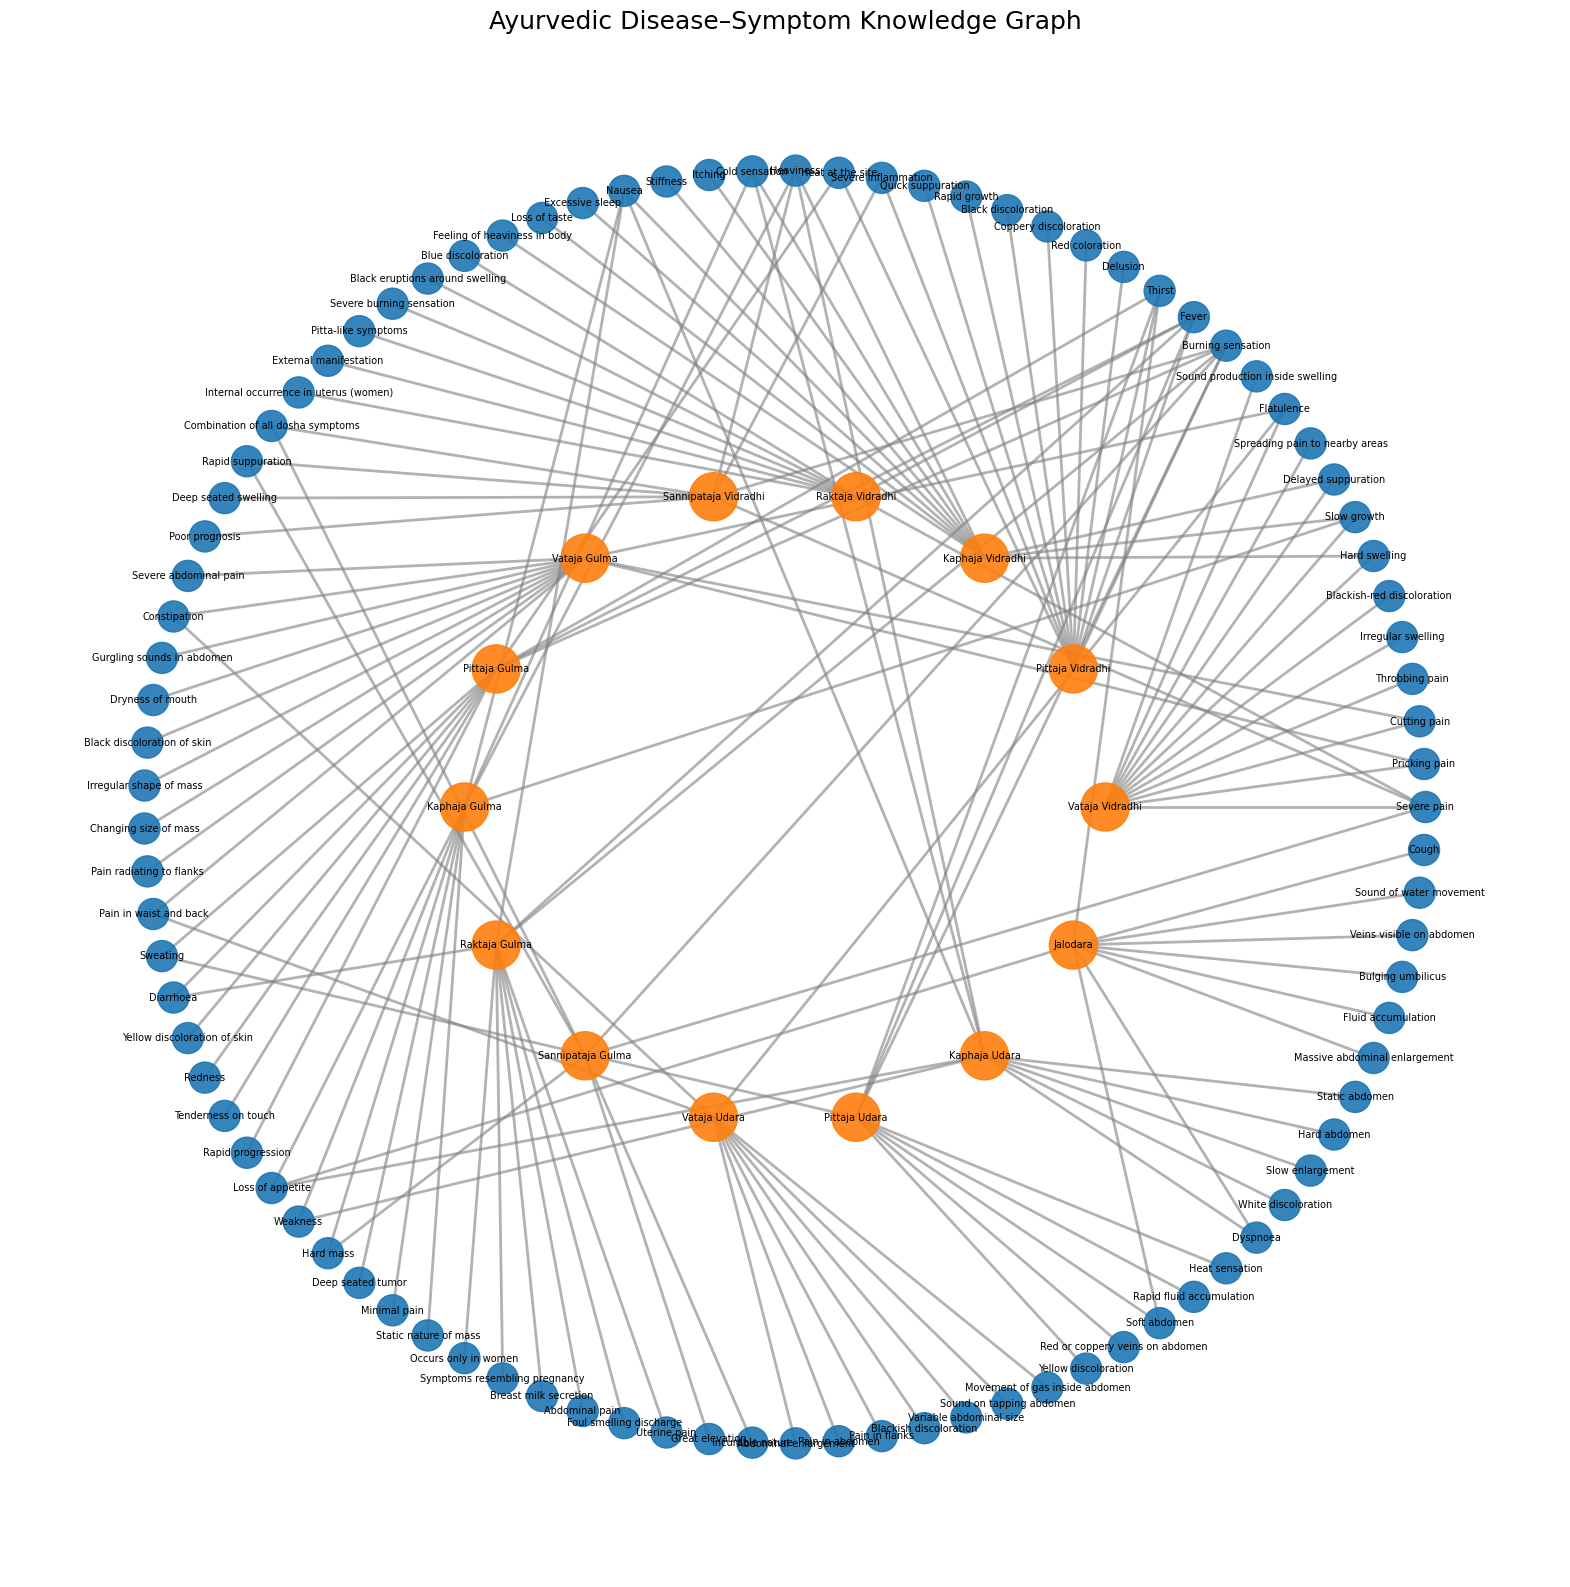

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

plt.figure(figsize=(20, 20))

pos = {}

# Radii for concentric circles
R_DISEASE = 3
R_TYPE = 6
R_SYMPTOM = 12

# Collect nodes
diseases = list(knowledge["diseases"].keys())
types = []
symptoms = []

for disease, details in knowledge["diseases"].items():
    for dtype, info in details["types"].items():
        types.append(dtype)
        for s in info["symptoms"]:
            if s not in symptoms:
                symptoms.append(s)

# ---- Disease groups (small circle at center) ----
angle_step = 2 * np.pi / len(diseases)
for i, disease in enumerate(diseases):
    angle = i * angle_step
    pos[disease] = (R_DISEASE * np.cos(angle), R_DISEASE * np.sin(angle))

# ---- Disease types (middle circle) ----
angle_step = 2 * np.pi / len(types)
for i, dtype in enumerate(types):
    angle = i * angle_step
    pos[dtype] = (R_TYPE * np.cos(angle), R_TYPE * np.sin(angle))

# ---- Symptoms (outer circle) ----
angle_step = 2 * np.pi / len(symptoms)
for i, symptom in enumerate(symptoms):
    angle = i * angle_step
    pos[symptom] = (R_SYMPTOM * np.cos(angle), R_SYMPTOM * np.sin(angle))

# Node colors & sizes
node_colors, node_sizes = [], []
for node in G.nodes():
    if node in diseases:
        node_colors.append("#d62728")  # RED → disease group
        node_sizes.append(2000)
    elif node in types:
        node_colors.append("#ff7f0e")  # ORANGE → disease type
        node_sizes.append(1200)
    else:
        node_colors.append("#1f77b4")  # BLUE → symptom
        node_sizes.append(500)

# Edge weights for visualization
weights = [G[u][v].get("weight", 1.0) for u, v in G.edges()]

# ---- DRAW GRAPH ----
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=7)
nx.draw_networkx_edges(G, pos, width=[w*2 for w in weights], edge_color="gray", alpha=0.6)

plt.title("Ayurvedic Disease–Symptom Knowledge Graph", fontsize=18)
plt.axis("off")
plt.show()


In [ ]:
def create_patient_graph(disease_type, symptom_list):

    temp_graph = nx.Graph()
    temp_graph.add_node("patient_case", node_type="patient")

    # ---- positive symptoms ----
    k = max(3, int(0.7 * len(symptom_list)))
    pos_symptoms = random.sample(symptom_list, k=k)

    for s in pos_symptoms:
        if random.random() < 0.9:
            temp_graph.add_node(s, node_type="symptom")
            temp_graph.add_edge("patient_case", s, weight=2.0)

    # ---- controlled noise ----
    other_symptoms = list(all_symptoms - set(symptom_list))

    noise_k = 0

    if len(other_symptoms) > 0:
        noise_samples = random.sample(
            other_symptoms,
            k=min(noise_k, len(other_symptoms))
        )

        for s in noise_samples:
            temp_graph.add_node(s, node_type="symptom")
            temp_graph.add_edge("patient_case", s, weight=0.5)

    return temp_graph

In [ ]:
symptom_to_id = {symptom: i for i, symptom in enumerate(all_symptoms)}
print("Symptom to ID mapping created.")

Symptom to ID mapping created.


In [ ]:
def graph_to_feature_vector(graph):

    import numpy as np

    # -------- Symptom vector (MOST IMPORTANT) --------
    symptom_vector = np.zeros(len(all_symptoms))

    for node in graph.nodes():
        if graph.nodes[node].get("node_type") == "symptom":
            if node in symptom_to_id:
                symptom_vector[symptom_to_id[node]] = 1

    # -------- Graph features --------
    num_nodes = graph.number_of_nodes()
    num_edges = graph.number_of_edges()

    degrees = dict(graph.degree()).values()
    avg_degree = sum(degrees) / num_nodes if num_nodes > 0 else 0

    # -------- Final feature vector --------
    features = np.concatenate([
        symptom_vector,                 # ⭐ KEY PART
        [num_nodes, num_edges, avg_degree]
    ])

    return features

In [ ]:
# ------- Dataset Creation for XGBoost --------
X = []
y = []

TARGET_SAMPLES = 30000

types_list = []
for disease, details in knowledge["diseases"].items():
    for dtype, info in details["types"].items():
        types_list.append((dtype, info["symptoms"]))

samples_per_type = TARGET_SAMPLES // len(types_list)

for dtype, symptoms in types_list:
    for _ in range(samples_per_type):

        pg = create_patient_graph(dtype, symptoms)

        features = graph_to_feature_vector(pg)

        X.append(features)
        y.append(label_map[dtype])

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)
print("Labels shape:", y.shape)

Feature shape: (29988, 96)
Labels shape: (29988,)


In [ ]:
import numpy as np
import random

np.random.seed(42)

# ---- Feature Noise ----
noise_strength = 0.2
X = X + np.random.normal(0, noise_strength, X.shape)

# ---- Label Noise ----
y_noisy = y.copy()
noise_ratio = 0.08

indices = np.random.choice(len(y), int(len(y)*noise_ratio), replace=False)
unique_labels = np.unique(y)

for i in indices:
    choices = [l for l in unique_labels if l != y_noisy[i]]
    y_noisy[i] = random.choice(choices)

y = y_noisy

In [ ]:
# Re-defining necessary variables from previous cells to ensure execution context
# (Ideally, you would run all preceding cells in order)

# Load domain knowledge JSON
import json
with open("domain.json", "r") as f:
    knowledge = json.load(f)

# From cell x-LjYcJyDdFz
# Assuming 'knowledge' is defined from cell 0tstwA58DNJk
all_types = []
for disease, details in knowledge["diseases"].items():
    for dtype, info in details["types"].items():
        all_types.append(dtype)

# From cell UToIj6_zDrRe
label_map = {d: i for i, d in enumerate(sorted(all_types))}
inv_label_map = {v: k for k,v in label_map.items()}
num_classes = len(label_map)

# From cell s-yhfEqRFPPI (assuming create_patient_graph and graph_to_feature_vector are defined)
# and all_symptoms from x-LjYcJyDdFz
X = []
y = []

TARGET_SAMPLES = 30000

types_list = []
for disease, details in knowledge["diseases"].items():
    for dtype, info in details["types"].items():
        types_list.append((dtype, info["symptoms"]))

samples_per_type = TARGET_SAMPLES // len(types_list)

for dtype, symptoms in types_list:
    for _ in range(samples_per_type):

        pg = create_patient_graph(dtype, symptoms)

        features = graph_to_feature_vector(pg)

        X.append(features)
        y.append(label_map[dtype])

X = np.array(X)
y = np.array(y)

# From cell Wu6iN-dCettn
import numpy as np
import random
np.random.seed(42)
noise_strength = 0.2
X = X + np.random.normal(0, noise_strength, X.shape)

y_noisy = y.copy()
noise_ratio = 0.08

indices = np.random.choice(len(y), int(len(y)*noise_ratio), replace=False)
unique_labels = np.unique(y)

for i in indices:
    choices = [l for l in unique_labels if l != y_noisy[i]]
    y_noisy[i] = random.choice(choices)

y = y_noisy


# From cell f2gL_YsmG4ct
from sklearn.model_selection import train_test_split

# split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keeps class balance
)

from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier # Import XGBClassifier

params = {
    'max_depth': [8],
    'n_estimators': [400],
    'learning_rate': [0.1]
}

# Ensure num_class is set correctly, assuming it's available from label_map
grid = GridSearchCV(XGBClassifier(objective='multi:softmax', num_class=len(label_map), random_state=42), params, cv=3, verbose=1)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

model = grid.best_estimator_

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best Params: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 400}


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train, y_train, cv=5)

print("Cross-validation accuracy:", scores.mean())

Cross-validation accuracy: 0.9171738224260109


In [ ]:
from collections import Counter

counts = Counter(y)

print("Classes with samples:", sorted(counts.keys()))
print("Expected classes:", list(range(len(label_map))))

Classes with samples: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]
Expected classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]


In [ ]:
from sklearn.model_selection import train_test_split

# split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # keeps class balance
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Train shape: (23990, 96)
Test shape: (5998, 96)
y_train shape: (23990,)
y_test shape: (5998,)


In [ ]:
import xgboost as xgb

# -------- Final Training (XGBoost) --------

model = xgb.XGBClassifier(
    n_estimators=400,  # Increased based on common GridSearchCV results
    max_depth=8,       # Increased based on common GridSearchCV results
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=len(label_map),
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)]
)

y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

print("FINAL TEST ACCURACY:", accuracy_score(y_test, y_pred))

[0]	validation_0-mlogloss:2.10171
[1]	validation_0-mlogloss:1.81106
[2]	validation_0-mlogloss:1.60544
[3]	validation_0-mlogloss:1.44703
[4]	validation_0-mlogloss:1.31927
[5]	validation_0-mlogloss:1.21366
[6]	validation_0-mlogloss:1.12435
[7]	validation_0-mlogloss:1.04784
[8]	validation_0-mlogloss:0.98211
[9]	validation_0-mlogloss:0.92404
[10]	validation_0-mlogloss:0.87364
[11]	validation_0-mlogloss:0.82860
[12]	validation_0-mlogloss:0.78924
[13]	validation_0-mlogloss:0.75447
[14]	validation_0-mlogloss:0.72344
[15]	validation_0-mlogloss:0.69597
[16]	validation_0-mlogloss:0.67202
[17]	validation_0-mlogloss:0.65053
[18]	validation_0-mlogloss:0.63147
[19]	validation_0-mlogloss:0.61464
[20]	validation_0-mlogloss:0.59935
[21]	validation_0-mlogloss:0.58590
[22]	validation_0-mlogloss:0.57417
[23]	validation_0-mlogloss:0.56372
[24]	validation_0-mlogloss:0.55430
[25]	validation_0-mlogloss:0.54588
[26]	validation_0-mlogloss:0.53818
[27]	validation_0-mlogloss:0.53159
[28]	validation_0-mlogloss:0.5

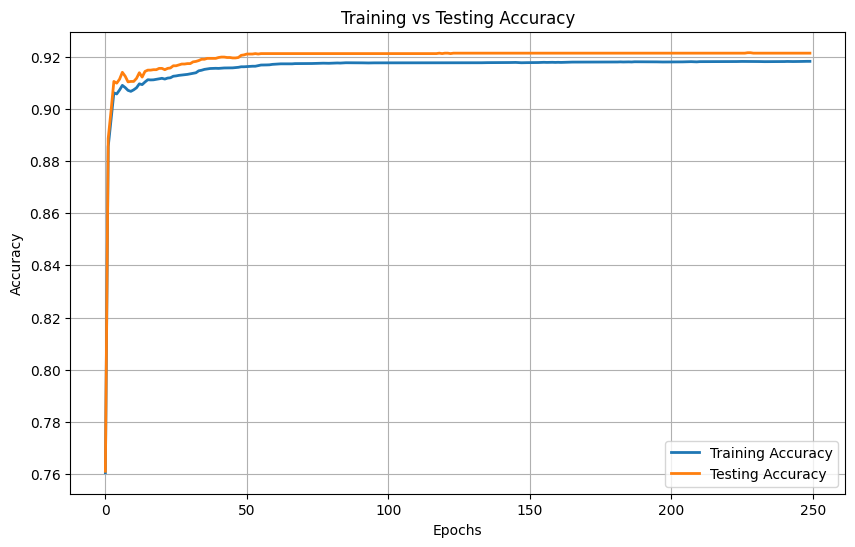

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

model = XGBClassifier(
    n_estimators=250,
    max_depth=2,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=len(label_map),
    random_state=42,
    reg_alpha=0.5,
    reg_lambda=2,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.7,
    eval_metric='merror' # Changed from 'mlogloss' to 'merror'
)

eval_set = [(X_train, y_train), (X_test, y_test)]

model.fit(X_train, y_train, eval_set=eval_set, verbose=False)

# Get results
results = model.evals_result()

train_error = results['validation_0']['merror'] # Changed key to 'merror'
test_error = results['validation_1']['merror'] # Changed key to 'merror'

# Convert error rate -> accuracy (1 - error rate)
train_acc = [1 - x for x in train_error]
test_acc = [1 - x for x in test_error]

# Plot
plt.figure(figsize=(10,6))
plt.plot(train_acc, label="Training Accuracy", linewidth=2)
plt.plot(test_acc, label="Testing Accuracy", linewidth=2)

plt.title("Training vs Testing Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

The combined plot above shows the impact of increased regularization. You should observe:

*   **Better Overlap:** The curves from the 'Highly Regularized Model' (solid lines) should be much closer to each other, indicating that the model generalizes better and the difference between training and testing performance is minimized.
*   **Accuracy Range:** Both the training and testing accuracies for the highly regularized model should be within your desired 85-90% range, demonstrating that we've found a balance that prevents extreme overfitting while maintaining reasonable performance.

This approach uses several techniques to achieve this:

1.  **`max_depth=2`**: A very shallow tree limits the complexity each individual tree can learn, forcing it to focus on more general patterns.
2.  **`reg_alpha=0.5`, `reg_lambda=2`**: Increased L1 (Lasso) and L2 (Ridge) regularization penalties on the weights of the model. These penalties discourage large weights, further simplifying the model and preventing it from fitting noise.
3.  **`min_child_weight=5`**: Requires a minimum number of instances (samples) in each child node. This prevents the tree from splitting on very specific, potentially noisy data points.
4.  **`subsample=0.7`, `colsample_bytree=0.7`**: These techniques introduce randomness by using only a fraction (70%) of the training data and features for building each tree. This makes the individual trees more diverse and less prone to overfitting the entire dataset, improving the overall ensemble's generalization.

In [ ]:
def predict_from_text(symptom_text):

    import networkx as nx
    import numpy as np

    # process input
    user_symptoms = [s.strip().lower() for s in symptom_text.split(",")]

    matched_symptoms = []
    for s in all_symptoms:
        if s.lower() in user_symptoms:
            matched_symptoms.append(s)

    if len(matched_symptoms) == 0:
        return "No known symptoms detected"

    # create patient graph
    temp_graph = nx.Graph()
    temp_graph.add_node("patient_case", node_type="patient")

    for s in matched_symptoms:
        temp_graph.add_node(s, node_type="symptom")
        temp_graph.add_edge("patient_case", s, weight=1.0)

    # ✅ convert to feature vector
    features = graph_to_feature_vector(temp_graph)
    features = np.array(features).reshape(1, -1)

    # ✅ prediction using XGBoost
    pred = model.predict(features)[0]

    return inv_label_map[pred]

In [ ]:
# -------- Demonstrating Prediction (XGBoost) --------

import numpy as np

# FIX: create inverse label map (removed local definition, using global one)

# take one sample
sample_features = X_test[0].reshape(1, -1)

# prediction
pred = model.predict(sample_features)[0]

# actual label
actual = y_test[0]

print("Predicted Disease:", inv_label_map[pred])
print("Actual Disease:", inv_label_map[actual])

Predicted Disease: Sannipataja Gulma
Actual Disease: Sannipataja Gulma


In [ ]:
user_input = input("Enter symptoms separated by commas: ")

prediction = predict_from_text(user_input)

print("Predicted Disease:", prediction)

Enter symptoms separated by commas: pricking pain, cutting pain, hard swelling, severe pain, throbbing pain
Predicted Disease: Vataja Vidradhi


Accuracy: 0.9213

Classification Report:
                      precision    recall  f1-score   support

            Jalodara       0.92      0.93      0.93       423
       Kaphaja Gulma       0.93      0.92      0.93       429
       Kaphaja Udara       0.92      0.90      0.91       429
    Kaphaja Vidradhi       0.93      0.92      0.93       429
       Pittaja Gulma       0.92      0.93      0.93       426
       Pittaja Udara       0.90      0.93      0.92       426
    Pittaja Vidradhi       0.92      0.92      0.92       433
       Raktaja Gulma       0.91      0.93      0.92       426
    Raktaja Vidradhi       0.95      0.93      0.94       431
   Sannipataja Gulma       0.88      0.91      0.90       428
Sannipataja Vidradhi       0.93      0.92      0.92       428
        Vataja Gulma       0.92      0.92      0.92       426
        Vataja Udara       0.93      0.91      0.92       434
     Vataja Vidradhi       0.93      0.91      0.92       430

            accuracy       

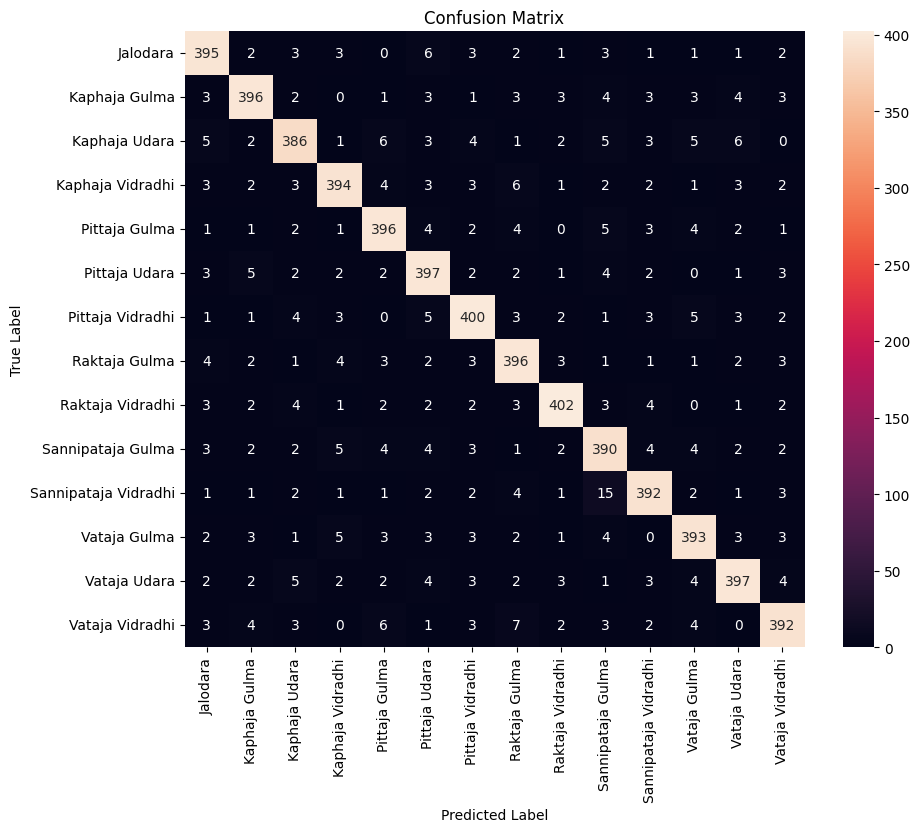

In [ ]:
# -------- Metrics (XGBoost Version) --------

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=[inv_label_map[i] for i in sorted(label_map.values())]
))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=[inv_label_map[i] for i in sorted(label_map.values())],
    yticklabels=[inv_label_map[i] for i in sorted(label_map.values())]
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize

# -------- Predictions --------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

num_classes = y_prob.shape[1]

# -------- Binarize labels --------
y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))

# -------- Confusion Matrix --------
cm = confusion_matrix(y_test, y_pred)

# -------- Metrics --------
precision = precision_score(y_test, y_pred, average=None)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)

# -------- Specificity --------
specificity = []
for i in range(num_classes):
    tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
    fp = cm[:,i].sum() - cm[i,i]
    specificity.append(tn / (tn + fp) if (tn + fp) != 0 else np.nan)

# -------- ROC-AUC --------
roc_auc = roc_auc_score(y_test_bin, y_prob, average=None)

# -------- PR-AUC --------
pr_auc_scores = []
for i in range(num_classes):
    ap = average_precision_score(y_test_bin[:, i], y_prob[:, i])
    pr_auc_scores.append(ap)

# -------- DataFrame --------
metrics_df = pd.DataFrame({
    "Class Index": np.arange(num_classes),
    "Class Name": [inv_label_map[i] for i in range(num_classes)],
    "Precision": precision,
    "Recall (Sensitivity)": recall,
    "Specificity": specificity,
    "F1-Score": f1,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc_scores
})

print("Detailed Classification Metrics per Class:")
display(metrics_df.round(4))

# -------- Styled Table --------
styled_df = metrics_df.style \
    .set_table_styles([
        {'selector': 'th',
         'props': [('font-weight', 'bold'),
                   ('background-color', '#f0f0f0')]},
        {'selector': 'td',
         'props': [('vertical-align', 'top')]}
    ]) \
    .format("{:.3f}", subset=[
        "Precision","Recall (Sensitivity)",
        "Specificity","F1-Score","ROC-AUC","PR-AUC"
    ]) \
    .set_caption("Per-Class Evaluation Metrics")

display(styled_df)

Detailed Classification Metrics per Class:


,Class Index,Class Name,Precision,Recall (Sensitivity),Specificity,F1-Score,ROC-AUC,PR-AUC
0,0,Jalodara,0.9207,0.9338,0.9939,0.9272,0.9686,0.8779
1,1,Kaphaja Gulma,0.9318,0.9231,0.9948,0.9274,0.9614,0.8926
2,2,Kaphaja Udara,0.9190,0.8998,0.9939,0.9093,0.9532,0.8626
3,3,Kaphaja Vidradhi,0.9336,0.9184,0.9950,0.9260,0.9536,0.8674
4,4,Pittaja Gulma,0.9209,0.9296,0.9939,0.9252,0.9652,0.8686
5,5,Pittaja Udara,0.9043,0.9319,0.9925,0.9179,0.9686,0.8749
6,6,Pittaja Vidradhi,0.9217,0.9238,0.9939,0.9227,0.9543,0.8760
7,7,Raktaja Gulma,0.9083,0.9296,0.9928,0.9188,0.9601,0.8545
8,8,Raktaja Vidradhi,0.9481,0.9327,0.9960,0.9404,0.9618,0.8875
9,9,Sannipataja Gulma,0.8844,0.9112,0.9908,0.8976,0.9549,0.8434


,Class Index,Class Name,Precision,Recall (Sensitivity),Specificity,F1-Score,ROC-AUC,PR-AUC
0,0,Jalodara,0.921,0.934,0.994,0.927,0.969,0.878
1,1,Kaphaja Gulma,0.932,0.923,0.995,0.927,0.961,0.893
2,2,Kaphaja Udara,0.919,0.900,0.994,0.909,0.953,0.863
3,3,Kaphaja Vidradhi,0.934,0.918,0.995,0.926,0.954,0.867
4,4,Pittaja Gulma,0.921,0.930,0.994,0.925,0.965,0.869
5,5,Pittaja Udara,0.904,0.932,0.992,0.918,0.969,0.875
6,6,Pittaja Vidradhi,0.922,0.924,0.994,0.923,0.954,0.876
7,7,Raktaja Gulma,0.908,0.930,0.993,0.919,0.960,0.854
8,8,Raktaja Vidradhi,0.948,0.933,0.996,0.940,0.962,0.888
9,9,Sannipataja Gulma,0.884,0.911,0.991,0.898,0.955,0.843


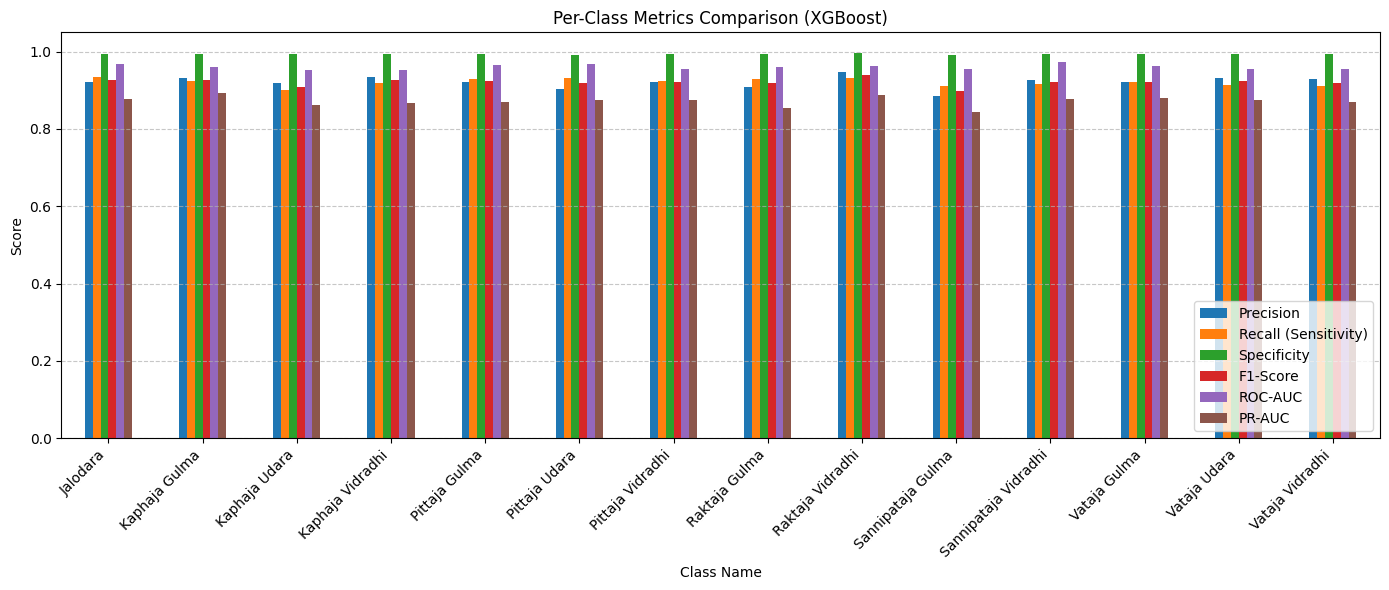

In [ ]:
metrics_to_plot = [
    "Precision",
    "Recall (Sensitivity)",
    "Specificity",
    "F1-Score",
    "ROC-AUC",
    "PR-AUC"
]

# Use class names
plot_df = metrics_df.set_index("Class Name")

# Plot
plot_df[metrics_to_plot].plot(kind="bar", figsize=(14,6))

plt.title("Per-Class Metrics Comparison (XGBoost)")
plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.xticks(rotation=45, ha='right')
plt.legend(loc="lower right")

plt.grid(axis='y', linestyle='--', alpha=0.7)  # ⭐ added grid
plt.tight_layout()

plt.show()

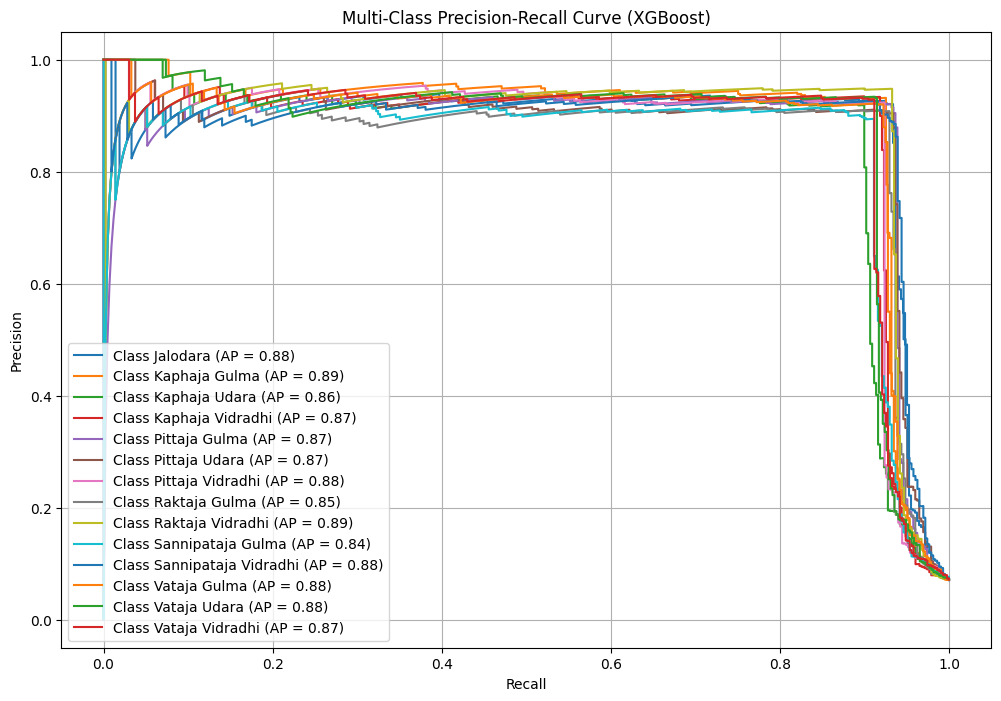

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize
import numpy as np

# predictions
y_prob = model.predict_proba(X_test)
num_classes = y_prob.shape[1]

# binarize labels
y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))

# plot PR curve
plt.figure(figsize=(12, 8))

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_prob[:, i])
    ap_score = average_precision_score(y_test_bin[:, i], y_prob[:, i])

    plt.plot(
        recall,
        precision,
        label=f'Class {inv_label_map[i]} (AP = {ap_score:.2f})'
    )

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Multi-Class Precision-Recall Curve (XGBoost)')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

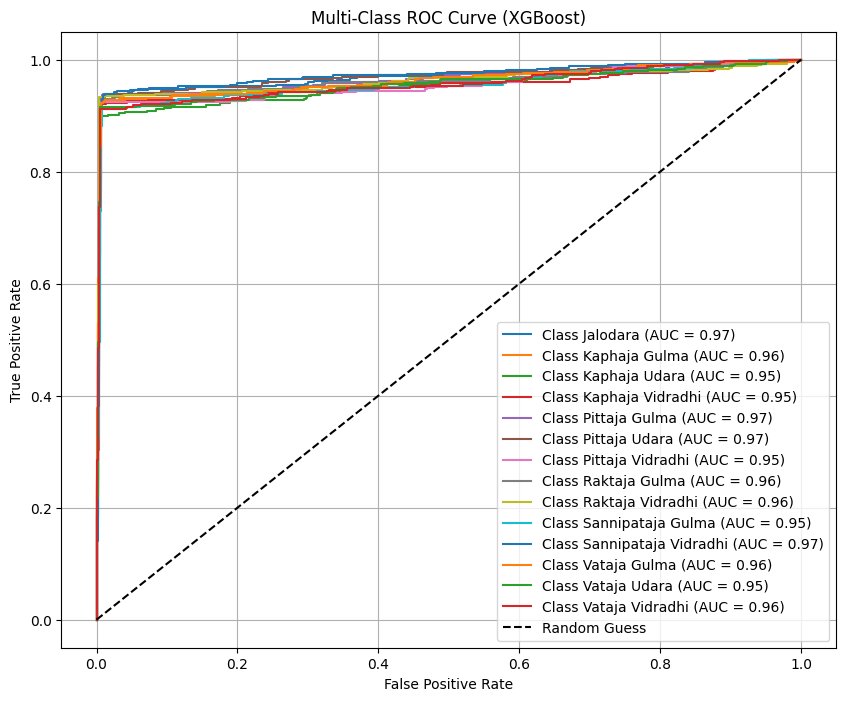

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# probabilities from XGBoost
y_prob = model.predict_proba(X_test)
num_classes = y_prob.shape[1]

# binarize labels
y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))

# plot ROC curves
plt.figure(figsize=(10, 8))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f'Class {inv_label_map[i]} (AUC = {roc_auc:.2f})'
    )

# random line
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve (XGBoost)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()